# Inconsistências de Artefatos em Bloco DCT

Implementação do artigo:

[1] S. Ye, Q. Sun, e E.-C. Chang, “Detecting Digital Image Forgeries by Measuring Inconsistencies of Blocking Artifact”, em Multimedia and Expo, 2007 IEEE International Conference on, Beijing, China: IEEE, jul. 2007, p. 12–15. doi: 10.1109/ICME.2007.4284574.

Autor: Paulo Max Gil Innocencio Reis 

Email: paulo.pmgir@pf.gov.br

Serviço de Perícias em Audiovisual e Eletrônicos - INC/DITEC

*Edições podem deixar inconsistências nos artefatos em bloco, no domínio da DCT*

# Importando pacotes

In [99]:
!pip install jpegio --proxy http://proxy.ditec.pf.gov.br:3128

Defaulting to user installation because normal site-packages is not writeable


In [100]:
import cv2
import numpy as np
import jpegio as jio
from matplotlib import pyplot as plt
from skimage import io
import estimativaq

# Inicialiazção de parâmetros

##### Escolha um dentre os três modos de operação

##### Modo 1 - Carrega a matriz de quantização a partir de uma imagem padrâo que se saiba, alegue ou suponha possuir a mesma matriz de quantização primária
##### Modo 2 - Carrega a matriz de quantização primária manualmente.
##### Modo 3 - Estima a matriz de quantizção a partir da imagem.

In [116]:
MaxCoeffs = 64
coeff = [1, 9, 2, 3, 10, 17, 25, 18, 11, 4, 5, 12, 19, 26, 33, 41, 34, 27, 20, 13, 6, 7, 14, 21, 
         28, 35, 42, 49, 57, 50, 43, 36, 29, 22, 15, 8, 16, 23, 30, 37, 44, 51, 58, 59, 52, 45, 38, 
         31, 24, 32, 39, 46, 53, 60, 61, 54, 47, 40, 48, 55, 62, 63, 56, 64]
image_path = "7.jpg"
image = io.imread(image_path)

Modo = 3 #Modo pode assumir valor 1 (carregar de padrão), 2 ( entrada manual), ou 3 (estimado)

if Modo == 1:
    #Modo numeoro 1: Carregar matriz de quantização primaria a partir de imagem padrao conhecida
    image_padrao = '21.jpeg'
    if image_path.lower().endswith(('.jpg', '.jpeg')):
        I_struct = jio.read(image_padrao)
        qtLum = I_struct.quant_tables[0]
    MatrizQ=qtLum
    print(MatrizQ)
elif Modo ==2:
    #Modo numeoro 2: Carregar matriz de quantização primaria manualmente
    MatrizQ = np.array([
        [1, 1, 1,2, 3, 3, 5, 6],
        [1, 1, 2, 3, 4, 5, 6, 6],
        [1, 2, 3, 4, 5, 6, 6, 7],
        [2, 3, 4, 5, 6, 6, 7, 7],
        [2, 4, 5, 6, 6, 7, 7, 7],
        [4, 5, 6, 6, 7, 7, 7, 1],
        [4, 6, 6, 7, 7, 7, 8, 8],
        [6, 6, 7, 7, 7, 8, 8, 8]   
    ])
    print(MatrizQ)
elif Modo==3:
    #Modo numeoro 3: Estimar a matriz de quantização (Cuidado: não necessariamente a primária)
    MatrizQ=estimativaq.estimativaq(image_path)
    print(MatrizQ)

else:
    print('Erro: defina o modo de opeeração')

[[ 0.  0.  0.  6. 10. 16. 21. 26.]
 [ 0. 16. 19.  8. 10. 24. 26. 24.]
 [ 0.  0.  6. 10. 17. 24. 30. 26.]
 [13.  0. 19. 12. 20. 36. 34.  3.]
 [15. 19. 16. 23. 28. 44.  3.  3.]
 [10. 15. 23. 26. 32.  3.  3.  3.]
 [21. 27. 32. 36.  3.  3.  3.  3.]
 [30. 21.  0.  3.  3.  3.  3.  3.]]


# Definição de funções

In [117]:
# Definição da matriz de transformação DCT
T = np.array([
    [0.3536, 0.3536, 0.3536, 0.3536, 0.3536, 0.3536, 0.3536, 0.3536],
    [0.4904, 0.4157, 0.2778, 0.0975, -0.0975, -0.2778, -0.4157, -0.4904],
    [0.4619, 0.1913, -0.1913, -0.4619, -0.4619, -0.1913, 0.1913, 0.4619],
    [0.4157, -0.0975, -0.4904, -0.2778, 0.2778, 0.4904, 0.0975, -0.4157],
    [0.3536, -0.3536, -0.3536, 0.3536, 0.3536, -0.3536, -0.3536, 0.3536],
    [0.2778, -0.4904, 0.0975, 0.4157, -0.4157, -0.0975, 0.4904, -0.2778],
    [0.1913, -0.4619, 0.4619, -0.1913, -0.1913, 0.4619, -0.4619, 0.1913],
    [0.0975, -0.2778, 0.4157, -0.4904, 0.4904, -0.4157, 0.2778, -0.0975]
])

# Função para aplicar DCT em blocos 8x8
def aplicar_dct(Y):
    # Função que aplica a transformação DCT usando a matriz T
    def dct_block(block):
        return T @ block @ T.T

    # Obtendo as dimensões da imagem
    linhas, colunas = Y.shape
    
    # Inicializando a matriz para os coeficientes DCT
    YDCT = np.zeros_like(Y)
    
    # Aplicando a DCT bloco por bloco
    for i in range(0, linhas, 8):
        for j in range(0, colunas, 8):
            bloco = Y[i:i+8, j:j+8]
            YDCT[i:i+8, j:j+8] = np.round(dct_block(bloco))
    
    return YDCT

def bdct(a, n=8):
    # Gerar a matriz para a transformada DCT2 completa em ambas as direções
    dctm = bdctmtx(n)
    
    # Converter a imagem em vetores, aplicar a DCT e converter de volta para imagem
    v, rows, cols = im2vec(a, (n, n))
    b = vec2im(np.dot(dctm, v), (0, 0), (n, n), rows, cols)
    
    return b

def bdctmtx(n):
    # Meshgrid para índices de linhas e colunas
    c, r = np.meshgrid(np.arange(n), np.arange(n))
    
    # Calcular a matriz da transformada DCT2
    x = np.sqrt(2 / n) * np.cos(np.pi * (2 * c + 1) * r / (2 * n))
    x[0, :] /= np.sqrt(2)
    m = np.kron(x, x)
    
    return m

def im2vec(im, bsize, padsize=(0, 0)):
    bsize = np.array(bsize) + np.array([0, 0])
    padsize = np.array(padsize) + np.array([0, 0])
    if np.any(padsize < 0):
        raise ValueError('Pad size must not be negative.')

    imsize = im.shape
    y = bsize[0] + padsize[0]
    x = bsize[1] + padsize[1]
    rows = (imsize[0] + padsize[0]) // y
    cols = (imsize[1] + padsize[1]) // x

    t = np.zeros((y * rows, x * cols))
    imy = y * rows - padsize[0]
    imx = x * cols - padsize[1]
    t[:imy, :imx] = im[:imy, :imx]
    t = t.reshape(y, rows, x, cols).transpose(1, 3, 0, 2)
    t = t.reshape(y, x, rows * cols)
    v = t[:bsize[0], :bsize[1], :rows * cols]
    v = v.reshape(bsize[0] * bsize[1], rows * cols)
    return v, rows, cols

def vec2im(v, padsize=(0, 0), bsize=None, rows=None, cols=None):
    m, n = v.shape
    if padsize is None:
        padsize = [0, 0]
    padsize = np.array(padsize) + np.array([0, 0])
    if np.any(padsize < 0):
        raise ValueError('Pad size must not be negative.')

    if bsize is None:
        bsize = [int(np.sqrt(m)), int(np.sqrt(m))]
    bsize = np.array(bsize) + np.array([0, 0])
    if np.prod(bsize) != m:
        raise ValueError('Block size does not match size of input vectors.')

    if rows is None:
        rows = int(np.sqrt(n))
    if cols is None:
        cols = int(np.ceil(n / rows))

    y = bsize[0] + padsize[0]
    x = bsize[1] + padsize[1]
    t = np.zeros((y, x, rows * cols))
    t[:bsize[0], :bsize[1], :n] = v.reshape(bsize[0], bsize[1], n)
    t = t.reshape(y, x, rows, cols).transpose(0, 2, 1, 3)
    t = t.reshape(y * rows, x * cols)
    im = t[:y * rows - padsize[0], :x * cols - padsize[1]]
    return im

# Cálculo dos artefatos DCT

In [118]:
im = np.double(image)
    
# Converte a imagem de RGB para Y (luminância)
Y = 0.299 * im[:, :, 0] + 0.587 * im[:, :, 1] + 0.114 * im[:, :, 2]

# Ajusta o tamanho da imagem para ser múltiplo de 8
linhas, colunas = Y.shape
Y = Y[:linhas - (linhas % 8), :colunas - (colunas % 8)]

# Subtrai 128 de cada pixel
Y = Y - 128

YDCT= aplicar_dct(Y)
#YDCT= np.round(bdct(Y))

imSize = Y.shape

D = np.tile(MatrizQ[:, :], (imSize[0] // 8, imSize[1] // 8))
BMat = np.abs(YDCT - np.round(YDCT / D) * D)
BMat[np.isnan(BMat)] = 0

/tmp/ipykernel_1556039/972042685.py:19: RuntimeWarning: divide by zero encountered in divide
  BMat = np.abs(YDCT - np.round(YDCT / D) * D)
/tmp/ipykernel_1556039/972042685.py:19: RuntimeWarning: invalid value encountered in divide
  BMat = np.abs(YDCT - np.round(YDCT / D) * D)
/tmp/ipykernel_1556039/972042685.py:19: RuntimeWarning: invalid value encountered in multiply
  BMat = np.abs(YDCT - np.round(YDCT / D) * D)


# Cálculo da matriz de artefatos DCT

In [119]:
# BMat_sum = np.sum(BMat, axis=(0, 1))
# BMat_matriz = BMat_sum.reshape(int(imSize[0] / 8), int(imSize[1] / 8))

# Inicializa a matriz de saída
BMat_matriz = np.zeros((imSize[0] // 8, imSize[1] // 8))

# Processa cada bloco de 8x8 pixels
for i in range(imSize[0] // 8):
    for j in range(imSize[1] // 8):
        # Extrai o bloco atual
        bloco = BMat[i*8:(i+1)*8, j*8:(j+1)*8]
        # Calcula a média do bloco e armazena na matriz decimada
        BMat_matriz[i, j] = np.mean(bloco)
 

# Visualização da imagem de artefatos DCT

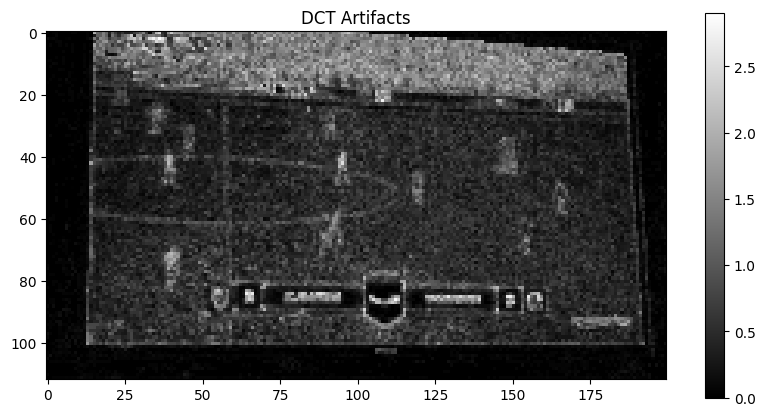

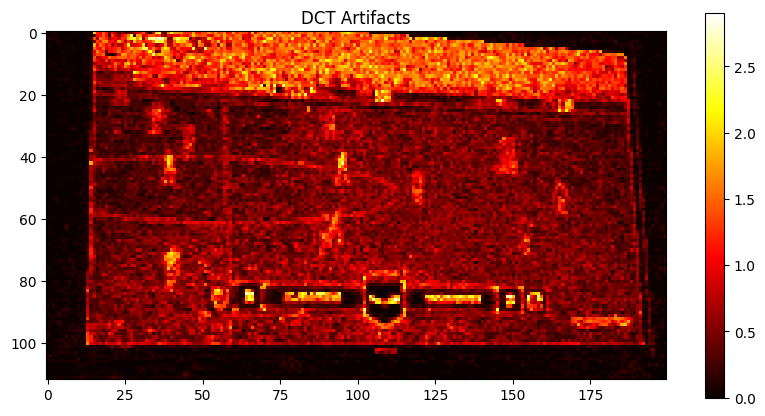

In [120]:
# Visualizar os artefatos de DCT
plt.figure(figsize=(10, 5))
#plt.subplot(1, 2, 1)
plt.imshow(BMat_matriz, cmap='gray')
plt.title('DCT Artifacts')
plt.colorbar()

plt.figure(figsize=(10, 5))
#plt.subplot(1, 2, 2)
plt.imshow(BMat_matriz, cmap='hot')
plt.title('DCT Artifacts')
plt.colorbar()

plt.show()